# ESS DAY 1 — 세 배치 EDA와 모델 전략

대상: Kaggle에서 받은 `2017-05-12`(Batch 1), `2018-02-20`(Batch 2), `2018-04-12`(Batch 3) 원본 `.mat`. `2018-04-03 varcharge`는 별도 실험 데이터라 제외합니다. 먼저 프로젝트 루트에서 `python src/preprocess.py`를 실행하고 이 노트북을 실행하세요. 원본 HDF5에서 필요한 배열만 읽어 `data/processed/`에 세 CSV를 저장합니다.

**분석 단위:** 셀 1개를 독립 표본으로 취급합니다. 총 139개 원본 기록 중 `cycle_life` 결측은 10개입니다. Batch 1에는 레이블은 있지만 마지막 Qd가 0.885 Ah보다 높은 기록 10개가 있습니다. 여기서는 이들을 **종료점 미확인**으로 표시합니다. 0.885 Ah는 0.88 Ah 종료 기준 근처를 판별하기 위한 QC 허용값이지 종료의 증명이 아닙니다. 수명과의 관계, 열화 속도 및 모델 전략은 레이블과 종료점 표시가 모두 있는 119개로 계산합니다. 제외 현황을 아래에서 모두 공개합니다.

**비교 범위:** 이 Kaggle 파일 구성은 [원논문 저자 코드](https://github.com/rdbraatz/data-driven-prediction-of-battery-cycle-life-before-capacity-degradation/blob/master/LoadData.m)가 사용하는 `2017-06-30` Batch 2와 다릅니다. 따라서 아래 결과를 원논문의 124셀 재현 수치라고 부르지 않습니다.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'data' / 'processed' / 'cells.csv').is_file()), None)
if ROOT is None:
    raise FileNotFoundError('프로젝트 루트에서 python src/preprocess.py를 먼저 실행하세요.')
OUT = ROOT / 'data' / 'processed'
cells = pd.read_csv(OUT / 'cells.csv')
traj = pd.read_csv(OUT / 'qd_trajectories.csv')
curves = pd.read_csv(OUT / 'delta_q_curves.csv')
usable = cells[cells.cycle_life.notna() & cells.endpoint_near_eol].copy()
BATCHES = ['Batch 1', 'Batch 2', 'Batch 3']
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': .2})
print('Source:', OUT.relative_to(ROOT))
print('raw cells:', len(cells), '| labeled:', cells.cycle_life.notna().sum(), '| analysis cohort:', len(usable))
print('trajectory rows:', len(traj), '| ΔQ(V) points:', len(curves))

Source: data/processed
raw cells: 139 | labeled: 129 | analysis cohort: 119
trajectory rows: 115706 | ΔQ(V) points: 139000


## 0. 데이터 품질과 분석 대상

`endpoint_near_eol`은 해당 파일에서 관측한 마지막 Qd가 0.885 Ah 이하인지 표시합니다. 레이블이 없거나 종료점이 확인되지 않은 셀은 **수명 연관 분석**에서 제외하되, 원본 기록 수에는 포함합니다. Qd=0인 Batch 1 첫 요약값은 측정 아티팩트로 보고 궤적 CSV에서 제외했습니다. ΔQ(V)는 `summary.cycle` 값이 정확히 100인 곡선에서 10인 곡선을 뺍니다.

In [2]:
quality = cells.groupby('batch', sort=False).agg(
    raw_cells=('cell_id','size'), labeled=('cycle_life','count'),
    near_eol=('endpoint_near_eol','sum'))
quality['analysis_cohort'] = usable.groupby('batch').size()
quality['missing_label'] = quality.raw_cells - quality.labeled
quality['labeled_endpoint_unconfirmed'] = quality.labeled - quality.analysis_cohort
print(quality.to_string())
assert quality.raw_cells.to_dict() == {'Batch 1':46,'Batch 2':47,'Batch 3':46}
assert len(usable) == 119 and usable.cell_id.is_unique
assert set(usable.cell_id).issubset(set(traj.cell_id) & set(curves.cell_id))
assert (curves.groupby('cell_id').size() == 1000).all()
print('분석에서 빠진 셀:', cells.loc[~cells.cell_id.isin(usable.cell_id),
      ['cell_id','batch','cycle_life','last_qd','endpoint_near_eol']].to_string(index=False))

         raw_cells  labeled  near_eol  analysis_cohort  missing_label  labeled_endpoint_unconfirmed
batch                                                                                              
Batch 1         46       46        36               36              0                            10
Batch 2         47       39        43               39              8                             0
Batch 3         46       44        44               44              2                             0
분석에서 빠진 셀: cell_id   batch  cycle_life  last_qd  endpoint_near_eol
   1_01 Batch 1      1190.0 1.026210              False
   1_02 Batch 1      1179.0 1.038225              False
   1_03 Batch 1      1177.0 1.043279              False
   1_04 Batch 1      1226.0 0.970921              False
   1_05 Batch 1      1227.0 1.021960              False
   1_09 Batch 1       879.0 0.969025              False
   1_11 Batch 1       906.0 0.961019              False
   1_13 Batch 1       902.0 0.913119     

## 1. Cycle Life 분포와 단수명 셀

150–2,300 사이클 범위에서 배치별 히스토그램을 그리고, 단수명(<500)·장수명(>1,000) 비율을 **분석 대상 셀** 기준으로 계산합니다. 실제 관측 범위와 표시 범위를 구분하고, 최단수명 셀이 같은 배치에서도 통계적 이상치인지 사분위범위(IQR)로 확인합니다. 짧은 수명의 원인은 관찰 자료만으로 확정할 수 없으므로 같은 배치 내 초기 ΔQ(V)와 충전 정책을 함께 살펴봅니다.


          n  median    q25     q75    min     max  short_n  short_pct  long_n  long_pct
batch                                                                                  
Batch 1  36   772.5  681.0   871.5  534.0  1074.0        0        0.0       5      13.9
Batch 2  39   472.0  439.5   508.5  392.0  1186.0       28       71.8       3       7.7
Batch 3  44  1005.5  828.0  1155.2  541.0  1935.0        0        0.0      23      52.3


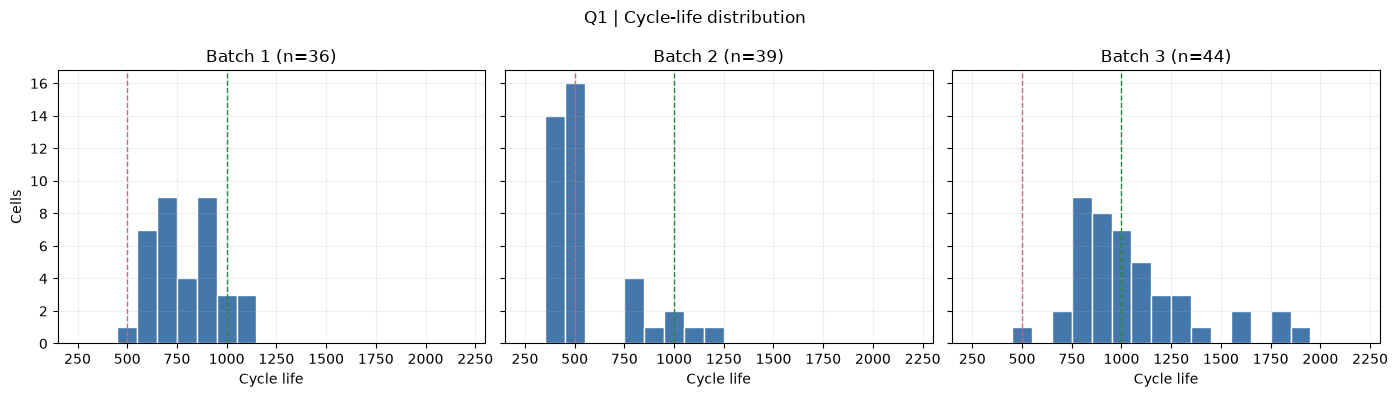


Shortest labeled cells:
 cell_id   batch  cycle_life          policy  ln_dq_variance
   2_20 Batch 2       392.0      6C(60%)-3C       -7.580013
   2_07 Batch 2       393.0     3.6C(9%)-5C       -8.128217
   2_16 Batch 2       396.0     3.6C(9%)-5C       -8.096469
   2_22 Batch 2       408.0      6C(60%)-3C       -7.659962
   2_31 Batch 2       412.0  5.6C(26%)-4.5C       -7.334677
   2_06 Batch 2       416.0    3.6C(30%)-6C       -7.105505
   2_03 Batch 2       424.0 5.2C(50%)-4.25C       -7.967516
   2_32 Batch 2       425.0  5.6C(26%)-4.5C       -7.719091

Batch 2 short vs other medians:
        cycle_life  ln_dq_variance  dq_min  charge_current_10
short                                                       
False       841.0          -9.744  -0.024              2.451
True        449.5          -7.935  -0.056              2.023

Overall: n=119, short=28 (23.5%), long=31 (26.1%), observed range=392–1935 cycles
Batch 2 lower IQR fence: 336 cycles; shortest cell: 2_20 (392 cycles)
Sam

In [3]:
life_rows=[]
for batch, d in usable.groupby('batch', sort=False):
    life_rows.append({'batch':batch,'n':len(d),'median':d.cycle_life.median(),
        'q25':d.cycle_life.quantile(.25),'q75':d.cycle_life.quantile(.75),
        'min':d.cycle_life.min(),'max':d.cycle_life.max(),
        'short_n':int((d.cycle_life<500).sum()),'short_pct':100*(d.cycle_life<500).mean(),
        'long_n':int((d.cycle_life>1000).sum()),'long_pct':100*(d.cycle_life>1000).mean()})
life_table=pd.DataFrame(life_rows).set_index('batch')
print(life_table.round(1).to_string())
fig, axes=plt.subplots(1,3,figsize=(14,4),sharey=True)
for ax,batch in zip(axes,BATCHES):
    d=usable[usable.batch==batch]
    ax.hist(d.cycle_life,bins=np.arange(150,2351,100),color='#4477AA',edgecolor='white')
    ax.axvline(500,color='#CC6677',ls='--',lw=1)
    ax.axvline(1000,color='#228833',ls='--',lw=1)
    ax.set(title=f'{batch} (n={len(d)})',xlabel='Cycle life',xlim=(150,2300))
axes[0].set_ylabel('Cells')
fig.suptitle('Q1 | Cycle-life distribution'); plt.tight_layout(); plt.show()
print('\nShortest labeled cells:\n',usable.nsmallest(8,'cycle_life')
      [['cell_id','batch','cycle_life','policy','ln_dq_variance']].to_string(index=False))
b2=usable[usable.batch=='Batch 2'].copy()
b2['short']=b2.cycle_life<500
print('\nBatch 2 short vs other medians:\n',b2.groupby('short')
      [['cycle_life','ln_dq_variance','dq_min','charge_current_10']].median().round(3).to_string())
print('\nOverall: n={}, short={} ({:.1f}%), long={} ({:.1f}%), observed range={:.0f}–{:.0f} cycles'.format(
    len(usable), int((usable.cycle_life<500).sum()), 100*(usable.cycle_life<500).mean(),
    int((usable.cycle_life>1000).sum()), 100*(usable.cycle_life>1000).mean(),
    usable.cycle_life.min(), usable.cycle_life.max()))
q1,q3=b2.cycle_life.quantile([.25,.75])
lower_fence=q1-1.5*(q3-q1)
shortest=b2.loc[b2.cycle_life.idxmin()]
same_policy=b2[(b2.policy==shortest.policy) & (b2.cell_id!=shortest.cell_id)]
print(f'Batch 2 lower IQR fence: {lower_fence:.0f} cycles; shortest cell: {shortest.cell_id} ({shortest.cycle_life:.0f} cycles)')
print('Same-policy peers in Batch 2:\n',same_policy[['cell_id','cycle_life','policy']].to_string(index=False))

**Q1 핵심 해석:** 분석 대상 119개의 실제 수명은 392–1,935회입니다. 전체 단수명은 28개(23.5%), 장수명은 31개(26.1%)이지만 배치 간 분포는 크게 다릅니다. Batch 2에서는 39개 중 28개(71.8%)가 500회 미만이고, Batch 1·3에는 500회 미만이 없습니다. 반대로 Batch 3에서는 44개 중 23개(52.3%)가 1,000회를 넘습니다. 따라서 전체 히스토그램만으로 수명 분포를 요약하면 배치 차이를 놓칩니다.

**최단수명 셀 점검:** `2_20`은 392회로 가장 짧지만, 같은 Batch 2·같은 정책(`6C(60%)-3C`)의 `2_22`도 408회입니다. Batch 2의 IQR 하한 336회보다 높으므로 `2_20`은 배치 내에서 고립된 통계적 이상치가 아닙니다. Batch 2의 단수명 그룹은 나머지 셀보다 초기 `ln Var[ΔQ(V)]` 중앙값이 높습니다(−7.935 대 −9.744). 초기 변화량과 짧은 수명이 연관될 수 있으나 충전 정책·셀 구조·배치 조건이 함께 달라 원인은 확정할 수 없습니다.

**모델링 시사점:** 초기 ΔQ(V) 요약값을 예측 피처 후보로 검토하고, 배치별 오차를 따로 보고합니다. Batch 1의 학습 대상에는 500회 미만 셀이 없으므로 이 기준의 이진 분류보다 연속형 Cycle Life 회귀를 우선합니다.


## 2. 방전 용량 열화와 knee 탐색

사이클별 Qd 궤적을 배치별로 시각화합니다. 각 셀의 전체 수명 `L`을 기준으로 `0.2L→0.6L`과 `0.6L→0.95L` 구간의 사이클당 용량 감소율을 비교해 열화가 일정한지 확인합니다. knee는 Qd 궤적에 두 직선을 맞춰 잔차제곱합이 가장 낮은 분할점으로 탐색하고, 절대 사이클 수 대신 수명 대비 위치로 비교합니다. **열화율과 knee는 전체 수명 및 후반 궤적을 사용한 사후 설명값**이므로 초기 예측 변수에 넣지 않습니다. 이 분할점은 물리적 변곡점의 확증이 아닙니다.


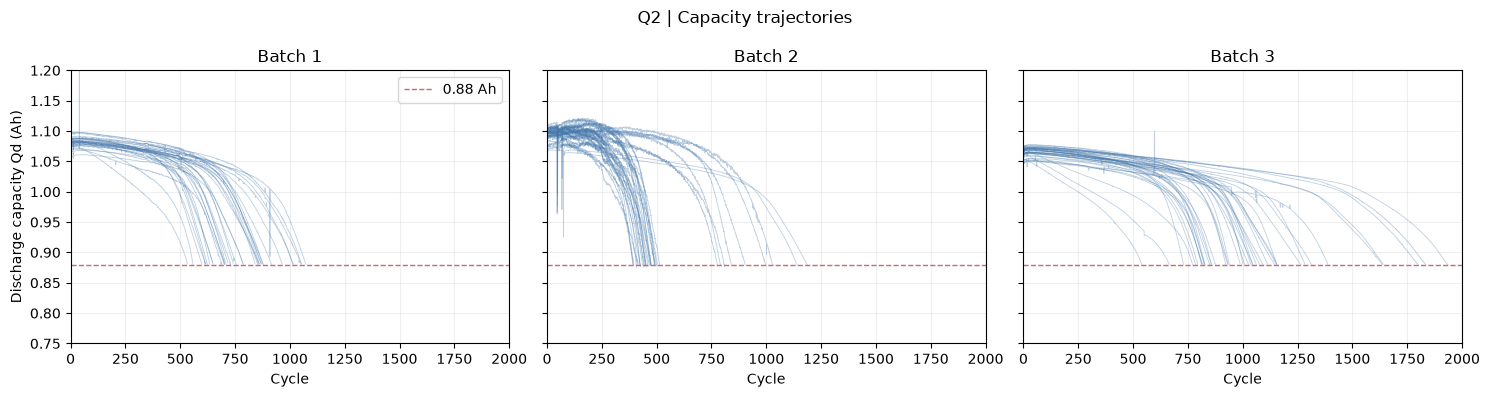

         early_mAh_per_cycle  late_mAh_per_cycle  knee_median  knee_q25  knee_q75  late_over_early  late_faster_pct
batch                                                                                                              
Batch 1                0.071               0.480        0.750      0.74      0.77            6.760            100.0
Batch 2                0.106               0.867        0.750      0.72      0.77            8.209            100.0
Batch 3                0.056               0.313        0.795      0.78      0.83            5.561            100.0


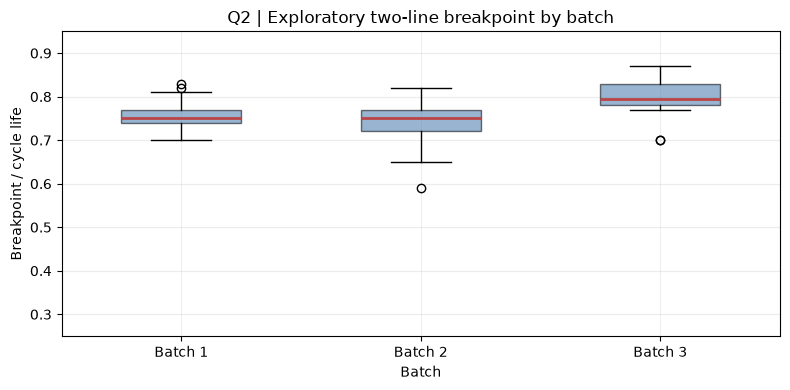

In [4]:
selected_traj=traj[traj.cell_id.isin(usable.cell_id)]
fig,axes=plt.subplots(1,3,figsize=(15,4),sharey=True)
for ax,batch in zip(axes,BATCHES):
    for _, d in selected_traj[selected_traj.batch==batch].groupby('cell_id'):
        ax.plot(d.cycle,d.qd,color='#4477AA',lw=.6,alpha=.35)
    ax.axhline(.88,color='#CC6677',ls='--',lw=1,label='0.88 Ah')
    ax.set(title=batch,xlabel='Cycle',xlim=(0,2000),ylim=(.75,1.2))
axes[0].set_ylabel('Discharge capacity Qd (Ah)'); axes[0].legend()
fig.suptitle('Q2 | Capacity trajectories'); plt.tight_layout(); plt.show()
fade=usable.groupby('batch',sort=False).agg(
    early_median=('early_fade','median'),late_median=('late_fade','median'),
    knee_median=('knee_fraction','median'),knee_q25=('knee_fraction',lambda s:s.quantile(.25)),
    knee_q75=('knee_fraction',lambda s:s.quantile(.75)))
fade['late_over_early']=fade.late_median/fade.early_median
fade['late_faster_pct']=usable.groupby('batch').apply(
    lambda d:100*(d.late_fade>d.early_fade).mean(),include_groups=False)
fade_display=fade.rename(columns={'early_median':'early_mAh_per_cycle', 'late_median':'late_mAh_per_cycle'}).copy()
fade_display[['early_mAh_per_cycle','late_mAh_per_cycle']] *= 1000
print(fade_display.round(3).to_string())
fig,ax=plt.subplots(figsize=(8,4))
knee_data=[usable.loc[usable.batch==batch,'knee_fraction'].dropna() for batch in BATCHES]
boxes=ax.boxplot(knee_data,tick_labels=BATCHES,patch_artist=True,widths=.5)
for box in boxes['boxes']:
    box.set(facecolor='#4477AA',alpha=.55)
for median in boxes['medians']:
    median.set(color='#BB4444',linewidth=2)
ax.set(xlabel='Batch',ylabel='Breakpoint / cycle life',ylim=(.25,.95),
       title='Q2 | Exploratory two-line breakpoint by batch')
ax.grid(axis='y',alpha=.25);plt.tight_layout();plt.show()

**Q2 핵심 해석:** 분석 대상 119개 셀 모두에서 후반(`0.6L→0.95L`) 구간의 사이클당 Qd 감소율이 앞 구간(`0.2L→0.6L`)보다 큽니다. 배치별 중앙 감소율은 Batch 1에서 0.071→0.480, Batch 2에서 0.106→0.867, Batch 3에서 0.056→0.313 mAh/사이클입니다. 중앙값의 후반/전반 비율은 각각 약 6.8·8.2·5.6배로, 열화 속도가 일정하기보다 수명 후반에 빨라지는 양상입니다.

**knee 해석:** 두 직선 피팅의 분할점 중앙값은 수명의 약 75%·75%·79.5%(Batch 1·2·3)입니다. 배치별 사분위범위는 각각 74–77%, 72–77%, 78–83%입니다. 이는 급격한 감소가 시작되는 시점을 찾기 위한 탐색적 지표입니다. 두 직선은 완만한 곡선에도 최적 분할점을 만들 수 있으므로 물리적으로 뚜렷한 knee가 모든 셀에 존재한다고 단정할 수 없습니다.

**모델링 시사점:** 후반 열화율과 knee는 수명 종료 후에만 계산되므로 예측 피처에서 제외합니다. 초기 Qd 궤적은 셀 간에 상당 부분 겹쳐 보여, 초기 100회 안의 작은 변화나 전압별 용량 차이(ΔQ(V))가 수명을 더 잘 구분하는지 다음 질문에서 검토합니다.


## 3. 초기 ΔQ(V) 곡선과 수명의 관계

각 셀의 공통 1,000점 전압 격자에서 **`ΔQ(V) = Qdlin(100번째 사이클, V) − Qdlin(10번째 사이클, V)`**를 계산합니다. 추출 과정은 `src/preprocess.py`에 있으며, 아래에서는 저장된 ΔQ(V)와 셀별 통계값을 확인합니다. 먼저 절대 기준의 단수명(<500회)·장수명(>1,000회) 셀을 비교하고, 배치 구성 차이의 영향을 살펴보기 위해 각 배치 안에서도 수명 하위·상위 25%를 비교합니다. 후보 피처는 전압축 로그 분산 `ln Varᵥ[ΔQ(V)]`와 최솟값 `minᵥ ΔQ(V)`입니다. 두 값 모두 100번째 사이클까지의 정보만 사용합니다.


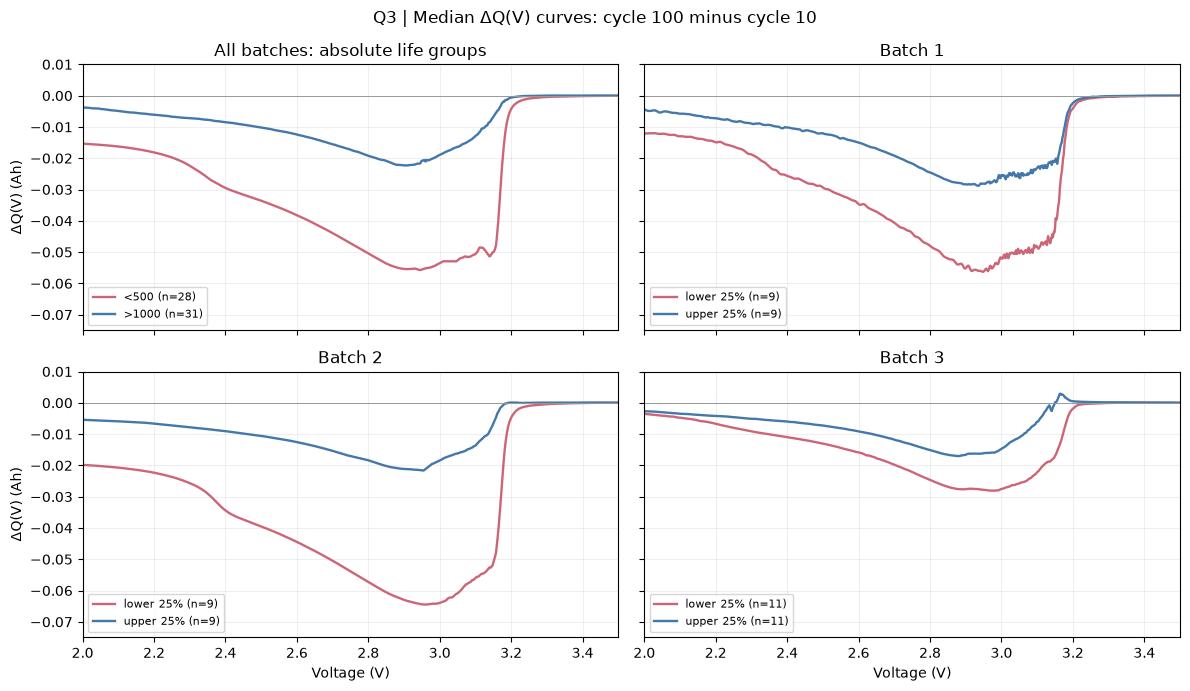

Feature medians by absolute life group:
                 short (<500)  long (>1000)
ln_dq_variance        -7.935        -9.836
dq_min                -0.056        -0.022

Absolute group composition by batch:
          short  long
batch               
Batch 1      0     5
Batch 2     28     3
Batch 3      0    23



Within-batch Spearman ρ with cycle life:
           n  rho_ln_variance  rho_dq_min
batch                                   
Batch 1  36           -0.826       0.787
Batch 2  39           -0.709       0.661
Batch 3  44           -0.797       0.776
Pooled Spearman ρ, ln variance vs cycle life: -0.888
Feature redundancy, Spearman ρ(ln variance, min ΔQ): -0.996


In [5]:
short=usable[usable.cycle_life<500]
long=usable[usable.cycle_life>1000]
fig,axes=plt.subplots(2,2,figsize=(12,7),sharex=True,sharey=True)
groups=[('All batches: absolute life groups',
         [(short.cell_id,f'<500 (n={len(short)})','#CC6677'),
          (long.cell_id,f'>1000 (n={len(long)})','#4477AA')])]
for batch,d in usable.groupby('batch',sort=False):
    d=d.sort_values('cycle_life')
    k=max(1,len(d)//4)
    groups.append((batch,[(d.head(k).cell_id,f'lower 25% (n={k})','#CC6677'),
                          (d.tail(k).cell_id,f'upper 25% (n={k})','#4477AA')]))
for ax,(title,series) in zip(axes.flat,groups):
    for ids,label,color in series:
        median_curve=curves[curves.cell_id.isin(ids)].groupby('voltage').delta_q.median()
        ax.plot(median_curve.index,median_curve.values,color=color,lw=1.7,label=label)
    ax.axhline(0,color='0.6',lw=.7)
    ax.set(title=title,xlim=(2,3.5),ylim=(-.075,.01))
    ax.legend(fontsize=8,loc='lower left')
for ax in axes[1]: ax.set_xlabel('Voltage (V)')
for ax in axes[:,0]: ax.set_ylabel('ΔQ(V) (Ah)')
fig.suptitle('Q3 | Median ΔQ(V) curves: cycle 100 minus cycle 10')
plt.tight_layout();plt.show()
feature_check=curves[curves.cell_id.isin(usable.cell_id)].groupby('cell_id').delta_q.agg(
    ln_variance=lambda s:np.log(np.var(s.to_numpy())),dq_min='min')
indexed=usable.set_index('cell_id')
assert np.allclose(feature_check.loc[indexed.index,'ln_variance'],indexed.ln_dq_variance)
assert np.allclose(feature_check.loc[indexed.index,'dq_min'],indexed.dq_min)
feature_medians=pd.DataFrame({
    'short (<500)':short[['ln_dq_variance','dq_min']].median(),
    'long (>1000)':long[['ln_dq_variance','dq_min']].median()})
print('Feature medians by absolute life group:\n',feature_medians.round(3).to_string())
print('\nAbsolute group composition by batch:\n',pd.DataFrame({
    'short':short.groupby('batch').size(),
    'long':long.groupby('batch').size()}).reindex(BATCHES).fillna(0).astype(int).to_string())
curve_corr=pd.DataFrame([{'batch':batch,'n':len(d),
    'rho_ln_variance':d.ln_dq_variance.corr(d.cycle_life,method='spearman'),
    'rho_dq_min':d.dq_min.corr(d.cycle_life,method='spearman')}
    for batch,d in usable.groupby('batch',sort=False)]).set_index('batch')
print('\nWithin-batch Spearman ρ with cycle life:\n',curve_corr.round(3).to_string())
print('Pooled Spearman ρ, ln variance vs cycle life:',
      round(usable.ln_dq_variance.corr(usable.cycle_life,method='spearman'),3))
print('Feature redundancy, Spearman ρ(ln variance, min ΔQ):',
      round(usable.ln_dq_variance.corr(usable.dq_min,method='spearman'),3))

**Q3 핵심 해석:** 100번째 사이클에서 10번째 사이클을 뺀 ΔQ(V) 중앙 곡선은 단수명(<500회) 그룹에서 약 2.9–3.0 V 부근의 음의 골이 더 깊습니다. 단수명·장수명 그룹의 셀별 `ln Varᵥ[ΔQ(V)]` 중앙값은 각각 −7.935·−9.836이고, `minᵥ ΔQ(V)` 중앙값은 −0.056·−0.022 Ah입니다. 즉 단수명 셀의 초기 전압별 용량 변화 폭이 더 큽니다. 다만 단수명 28개는 모두 Batch 2에 있고 장수명 31개 중 23개는 Batch 3에 있어, 절대 그룹 비교에는 배치 차이가 섞여 있습니다.

**배치 내부 확인:** 수명 하위·상위 25%의 ΔQ(V) 곡선을 각 배치 안에서 비교해도 짧은 쪽의 음의 골이 더 깊습니다. `ln Varᵥ[ΔQ(V)]`와 수명의 Spearman ρ는 Batch 1·2·3에서 각각 −0.826·−0.709·−0.797로 방향이 일관됩니다. 이는 초기 100회 내 변화가 수명을 구분할 수 있다는 근거이지만, 상관관계가 열화 원인을 증명하지는 않습니다.

**피처 선택 시사점:** 전압축 로그 분산과 최솟값 모두 후보 피처로 추출했습니다. 전체 셀에서 두 피처의 Spearman ρ는 −0.996으로 정보가 거의 겹치므로, 기본 모델에는 배치별 수명 관계가 안정적인 `ln Varᵥ[ΔQ(V)]`를 우선 사용하고 `minᵥ ΔQ(V)`는 중복 후보로 둡니다. 이 피처를 계산하려면 100번째 사이클까지 관측해야 합니다.


## 4. 충전 조건(C-rate)과 수명·열화 속도

충전 정책 문자열의 첫·둘째 구간 C-rate(`c1`, `c2`)와 전환 SOC(`switch_soc`)를 충전 **설정 패턴**으로, 10·100번째 사이클의 양(+)의 전류 표본 평균과 두 평균의 차이를 초기 **실측 전류 요약값**으로 사용합니다. 정책별 평균 수명은 배치별로 계산하고 표본이 2개 이상인 정책만 표시합니다. `newstructure` 표시는 같은 명목 C-rate라도 다른 실험 조건임을 구분해 읽습니다. 실측 평균 전류는 충전 구간 전체의 시간 적분이나 순간 전류 파형을 나타내지 않습니다. 후반 열화율은 전체 수명 자료로 만든 사후 설명값입니다.


Protocols with at least two analysis cells:
                                      n  mean_life  median_life
batch   policy                                                
Batch 1 8C(15%)-3.6C                 2     1008.5       1008.5
        6C(40%)-3C                   2      935.5        935.5
        6C(50%)-3C                   2      888.5        888.5
        5.4C(60%)-3.6C               2      859.5        859.5
        6C(40%)-3.6C                 2      856.0        856.0
        5.4C(60%)-3C                 2      799.5        799.5
        6C(50%)-3.6C                 2      792.5        792.5
        4.8C(80%)-4.8C               2      753.0        753.0
        6C(60%)-3C                   2      744.0        744.0
        5.4C(70%)-3C                 2      739.5        739.5
        7C(30%)-3.6C                 2      722.5        722.5
        8C(25%)-3.6C                 2      676.5        676.5
        7C(40%)-3C                   2      676.0        676.0
        7C

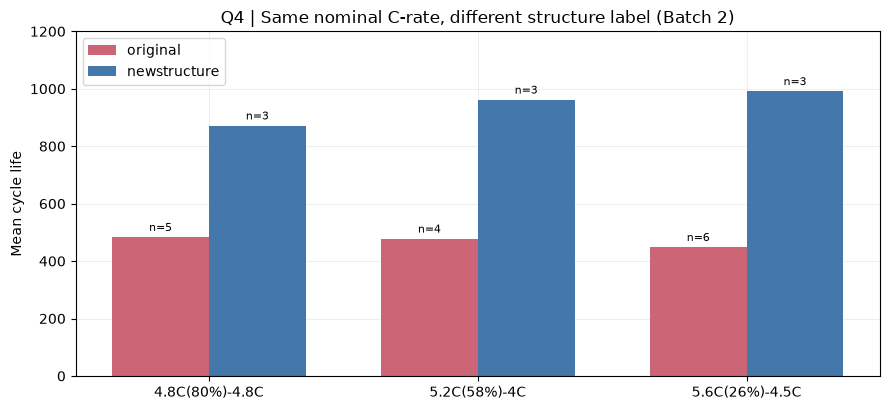

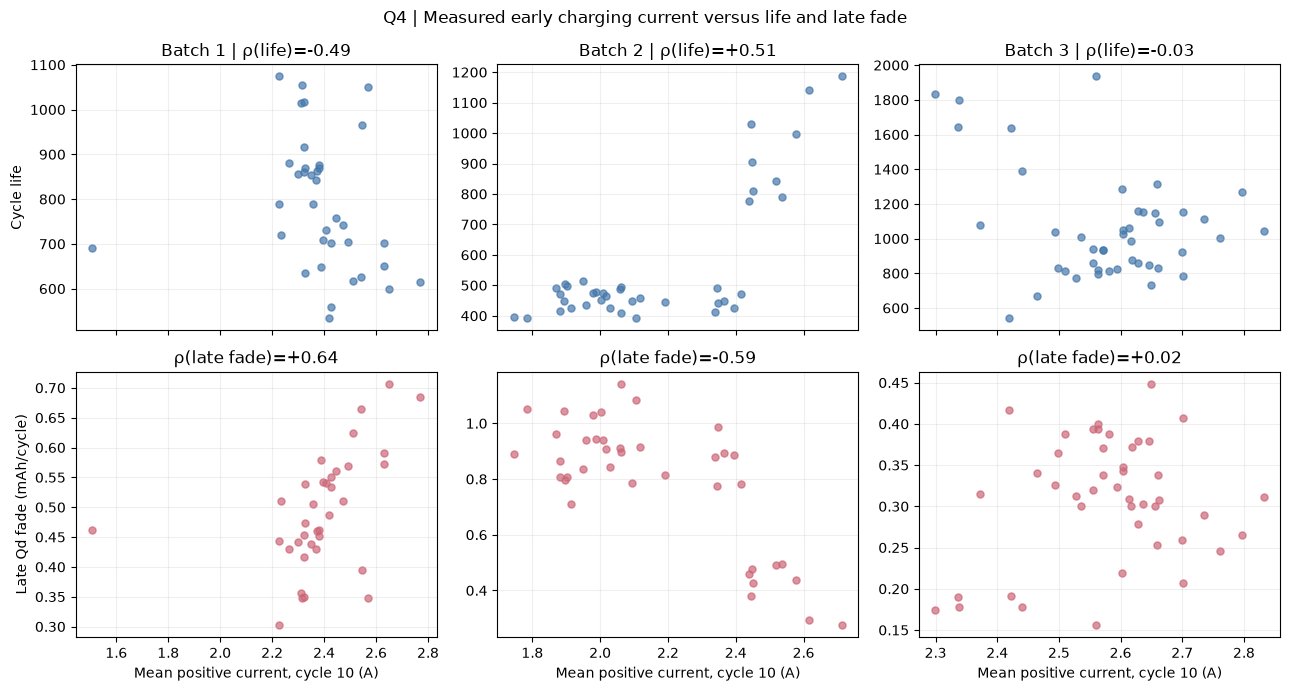


Within-batch Spearman ρ:
   batch               feature  rho_life  rho_late_fade
Batch 1                    c1    -0.237          0.431
Batch 1                    c2    -0.161          0.050
Batch 1            switch_soc    -0.059         -0.104
Batch 1     charge_current_10    -0.494          0.640
Batch 1    charge_current_100    -0.456          0.609
Batch 1 current_change_100_10     0.030         -0.042
Batch 2                    c1     0.055          0.008
Batch 2                    c2    -0.119         -0.137
Batch 2            switch_soc     0.288         -0.023
Batch 2     charge_current_10     0.506         -0.589
Batch 2    charge_current_100     0.472         -0.626
Batch 2 current_change_100_10    -0.058         -0.171
Batch 3                    c1    -0.229          0.394
Batch 3                    c2     0.016          0.018
Batch 3            switch_soc     0.443         -0.539
Batch 3     charge_current_10    -0.026          0.024
Batch 3    charge_current_100    -0.23

In [6]:
policy_stats=(usable.groupby(['batch','policy']).agg(
    n=('cell_id','size'),mean_life=('cycle_life','mean'),
    median_life=('cycle_life','median'))
    .query('n >= 2').sort_values(['batch','n','mean_life'],ascending=[True,False,False]))
print('Protocols with at least two analysis cells:\n',policy_stats.round(1).to_string())
bases=['4.8C(80%)-4.8C','5.2C(58%)-4C','5.6C(26%)-4.5C']
b2_policy=policy_stats.loc['Batch 2']
paired=pd.DataFrame([{'base':base,'structure':structure,
    'n':int(b2_policy.loc[name,'n']),'mean_life':b2_policy.loc[name,'mean_life']}
    for base in bases for structure,name in
    [('original',base),('newstructure',base+'-newstructure')]])
fig,ax=plt.subplots(figsize=(9,4.2))
x=np.arange(len(bases));width=.36
for offset,structure,color in [(-width/2,'original','#CC6677'),
                               (width/2,'newstructure','#4477AA')]:
    d=paired[paired.structure==structure].set_index('base').loc[bases]
    bars=ax.bar(x+offset,d.mean_life,width,color=color,label=structure)
    for bar,n in zip(bars,d.n):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+12,f'n={n}',
                ha='center',va='bottom',fontsize=8)
ax.set(xticks=x,xticklabels=bases,ylabel='Mean cycle life',
       ylim=(0,1200),title='Q4 | Same nominal C-rate, different structure label (Batch 2)')
ax.legend();ax.grid(axis='y',alpha=.2);ax.set_axisbelow(True)
plt.tight_layout();plt.show()
current=usable.copy()
current['current_change_100_10']=current.charge_current_100-current.charge_current_10
fig,axes=plt.subplots(2,3,figsize=(13,7),sharex='col')
for col,batch in enumerate(BATCHES):
    d=current[current.batch==batch]
    axes[0,col].scatter(d.charge_current_10,d.cycle_life,s=26,alpha=.7,color='#4477AA')
    axes[1,col].scatter(d.charge_current_10,d.late_fade*1000,s=26,alpha=.7,color='#CC6677')
    rho_life=d.charge_current_10.corr(d.cycle_life,method='spearman')
    rho_fade=d.charge_current_10.corr(d.late_fade,method='spearman')
    axes[0,col].set_title(f'{batch} | ρ(life)={rho_life:+.2f}')
    axes[1,col].set_title(f'ρ(late fade)={rho_fade:+.2f}')
    axes[1,col].set_xlabel('Mean positive current, cycle 10 (A)')
axes[0,0].set_ylabel('Cycle life')
axes[1,0].set_ylabel('Late Qd fade (mAh/cycle)')
fig.suptitle('Q4 | Measured early charging current versus life and late fade')
plt.tight_layout();plt.show()
features=['c1','c2','switch_soc','charge_current_10',
          'charge_current_100','current_change_100_10']
current_rows=[]
for batch,d in current.groupby('batch',sort=False):
    for feature in features:
        current_rows.append({'batch':batch,'feature':feature,
            'rho_life':d[feature].corr(d.cycle_life,method='spearman'),
            'rho_late_fade':d[feature].corr(d.late_fade,method='spearman')})
current_corr=pd.DataFrame(current_rows)
print('\nWithin-batch Spearman ρ:\n',current_corr.round(3).to_string(index=False))
print('\nBatch 2 paired protocol means:\n',paired.round(1).to_string(index=False))
b2_check=current[current.batch=='Batch 2'].copy()
b2_check['newstructure']=b2_check.policy.str.contains('newstructure')
structure_summary=b2_check.groupby('newstructure').agg(
    n=('cell_id','size'),median_life=('cycle_life','median'),
    median_current_10=('charge_current_10','median'))
print('\nBatch 2 structure-label groups:\n',structure_summary.round(3).to_string())
print('Batch 2 non-newstructure Spearman ρ(current10, life):',
      round(b2_check.loc[~b2_check.newstructure,'charge_current_10'].corr(
          b2_check.loc[~b2_check.newstructure,'cycle_life'],method='spearman'),3))

**Q4 프로토콜 비교:** Batch 2에서 같은 명목 C-rate의 세 정책 모두 `newstructure` 표시 그룹의 평균 수명이 더 길었습니다. 예를 들어 `5.6C(26%)-4.5C`는 6개 평균 448.5회, `-newstructure`는 3개 평균 991.3회입니다. 정책의 C-rate 숫자만으로 수명을 설명하기 어렵다는 사례이며, 구조 표시와 수명 차이의 인과관계를 증명하지는 않습니다. 대부분의 정책은 반복 수가 작아 평균은 기술 통계로 해석합니다.

**고속 충전 여부:** 첫 구간 C-rate(`c1`)와 수명의 Spearman ρ는 Batch 1·2·3에서 각각 −0.237·+0.055·−0.229로 약하거나 방향이 일정하지 않습니다. 10번째 사이클 평균 양(+)의 전류와 수명의 ρ도 −0.494·+0.506·−0.026으로 배치별 방향이 다릅니다. 따라서 이 데이터에서 “고속 충전 셀은 반드시 단수명”이라는 일반 결론은 지지되지 않습니다. 특히 Batch 2에서 `newstructure` 표시가 없는 30개만 보면 실측 초기 전류와 수명의 ρ는 −0.075로, 전체 Batch 2의 +0.506과 크게 다릅니다.

**실측 전류와 열화 속도:** 10번째 사이클 평균 양(+)의 전류와 후반 Qd 감소율의 Spearman ρ는 Batch 1에서 +0.640, Batch 2에서 −0.589, Batch 3에서 +0.024입니다. 100번째 사이클 평균 전류도 각각 +0.609·−0.626·+0.078로 유사한 배치 차이를 보입니다. 10→100번째 사이클 평균 전류 변화량의 상관은 −0.042·−0.171·−0.017로 약합니다. 설정된 첫 구간 C-rate와 후반 감소율의 상관은 +0.431·+0.008·+0.394, 둘째 구간은 +0.050·−0.137·+0.018입니다. 전류 전환 SOC와 후반 감소율의 상관은 −0.104·−0.023·−0.539로 Batch 3에서만 비교적 큽니다. 전체적으로 배치 전반에 걸친 일관된 관계가 약합니다. 이 요약값만으로 셀 내부 충전 전류 파형의 영향까지 판단할 수는 없습니다.

**모델링 시사점:** 충전 정책과 실측 전류를 단독 수명 결정 요인으로 취급하지 않습니다. 피처로 시험하더라도 배치별 성능과 상관 방향을 따로 확인하고, 후반 열화율은 미래 정보이므로 예측 입력에서 제외합니다.


## 5. 초기 신호와 Cycle Life의 상관·피처 중복

100번째 사이클까지 얻을 수 있는 14개 후보 피처의 수명 상관을 전체 셀과 각 배치 안에서 **Spearman ρ**로 비교합니다. 전체 상관만 크고 배치별 방향이 달라지는 신호를 구분합니다. 피처끼리의 Spearman·Pearson 상관과, 14개를 한 선형 모델에 모두 넣었을 때의 분산팽창계수(VIF)를 확인해 다중공선성 위험을 점검합니다. VIF는 최종 모델의 성능 평가가 아니라 후보 집합의 중복을 확인하는 진단값입니다.


Spearman ρ with cycle life:
                           All  Batch 1  Batch 2  Batch 3
ln_dq_variance         -0.888   -0.826   -0.709   -0.797
dq_min                  0.876    0.787    0.661    0.776
early_qd_slope         -0.241    0.500   -0.271    0.184
qd_10                  -0.571    0.163    0.077    0.130
qd_100                 -0.541    0.370    0.077    0.178
ir_10                  -0.423    0.211   -0.386    0.162
ir_100                 -0.376    0.247   -0.345    0.161
early_tavg_mean         0.331   -0.115    0.172    0.025
early_charge_time_mean -0.264    0.485   -0.391    0.202
charge_current_10       0.577   -0.494    0.506   -0.026
charge_current_100      0.570   -0.456    0.472   -0.235
c1                      0.077   -0.237    0.055   -0.229
switch_soc              0.085   -0.059    0.288    0.443
c2                     -0.121   -0.161   -0.119    0.016


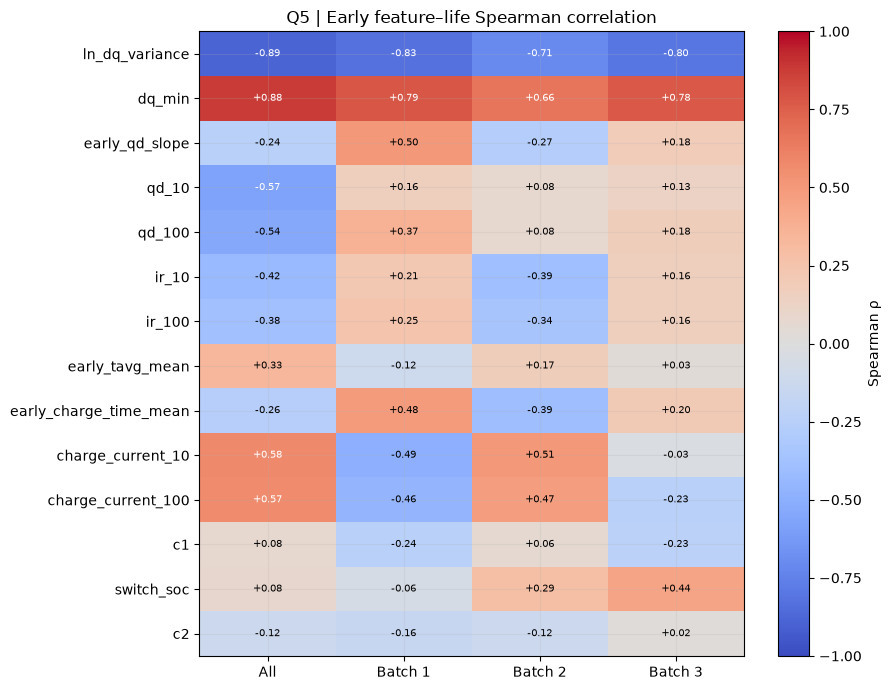


Strong feature pairs (|Spearman ρ| ≥ 0.9):
         feature_a          feature_b  spearman  pearson
   ln_dq_variance             dq_min    -0.996   -0.968
            qd_10             qd_100     0.967    0.960
            ir_10             ir_100     0.967    0.994
charge_current_10 charge_current_100     0.936    0.915


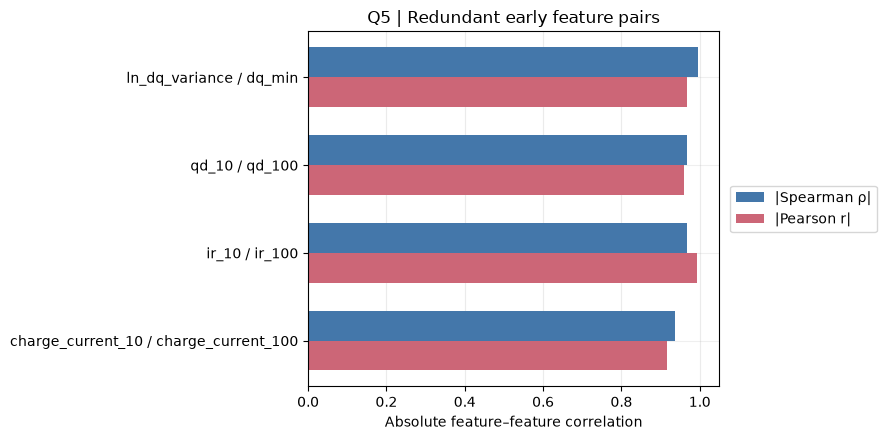


VIF, all 14 features (top 8):
 ir_100                334.2
ir_10                 330.3
qd_100                 98.1
qd_10                  84.0
dq_min                 23.3
ln_dq_variance         21.7
charge_current_100     18.7
charge_current_10      18.4
Maximum VIF after keeping one from each strong pair: 3.6
Strongest pooled |ρ|: ln_dq_variance 0.888


In [7]:
FEATURES=['ln_dq_variance','dq_min','early_qd_slope','qd_10','qd_100',
          'ir_10','ir_100','early_tavg_mean','early_charge_time_mean',
          'charge_current_10','charge_current_100','c1','switch_soc','c2']
assert usable[FEATURES].notna().all().all()
corr_table=pd.DataFrame({'All':{f:usable[f].corr(usable.cycle_life,method='spearman') for f in FEATURES},
    **{batch:{f:d[f].corr(d.cycle_life,method='spearman') for f in FEATURES}
       for batch,d in usable.groupby('batch',sort=False)}}).loc[FEATURES]
print('Spearman ρ with cycle life:\n',corr_table.round(3).to_string())
fig,ax=plt.subplots(figsize=(9,7))
im=ax.imshow(corr_table.to_numpy(),vmin=-1,vmax=1,cmap='coolwarm',aspect='auto')
ax.set(xticks=range(len(corr_table.columns)),xticklabels=corr_table.columns,
       yticks=range(len(FEATURES)),yticklabels=FEATURES,
       title='Q5 | Early feature–life Spearman correlation')
for row in range(len(FEATURES)):
    for col in range(len(corr_table.columns)):
        value=corr_table.iloc[row,col]
        ax.text(col,row,f'{value:+.2f}',ha='center',va='center',fontsize=7,
                color='white' if abs(value)>.55 else 'black')
fig.colorbar(im,ax=ax,label='Spearman ρ');plt.tight_layout();plt.show()
feature_spearman=usable[FEATURES].corr(method='spearman')
feature_pearson=usable[FEATURES].corr(method='pearson')
pairs=pd.DataFrame([{'feature_a':a,'feature_b':b,
    'spearman':feature_spearman.loc[a,b],
    'pearson':feature_pearson.loc[a,b]}
    for i,a in enumerate(FEATURES) for b in FEATURES[i+1:]
    if abs(feature_spearman.loc[a,b])>=.9])
print('\nStrong feature pairs (|Spearman ρ| ≥ 0.9):\n',pairs.round(3).to_string(index=False))
fig,ax=plt.subplots(figsize=(9,4.5))
y=np.arange(len(pairs));height=.34
ax.barh(y-height/2,pairs.spearman.abs(),height,label='|Spearman ρ|',color='#4477AA')
ax.barh(y+height/2,pairs.pearson.abs(),height,label='|Pearson r|',color='#CC6677')
ax.set(yticks=y,yticklabels=[f'{a} / {b}' for a,b in zip(pairs.feature_a,pairs.feature_b)],
       xlim=(0,1.05),xlabel='Absolute feature–feature correlation',
       title='Q5 | Redundant early feature pairs')
ax.invert_yaxis();ax.legend(loc='center left',bbox_to_anchor=(1.01,.5));ax.grid(axis='x',alpha=.25);ax.set_axisbelow(True)
plt.tight_layout();plt.show()
vif_all=pd.Series(np.diag(np.linalg.inv(feature_pearson.to_numpy())),index=FEATURES)
DEDUP=['ln_dq_variance','early_qd_slope','qd_100','ir_100',
       'early_tavg_mean','early_charge_time_mean',
       'charge_current_100','c1','switch_soc','c2']
vif_dedup=pd.Series(np.diag(np.linalg.inv(usable[DEDUP].corr().to_numpy())),index=DEDUP)
print('\nVIF, all 14 features (top 8):\n',vif_all.sort_values(ascending=False).head(8).round(1).to_string())
print('Maximum VIF after keeping one from each strong pair:',round(vif_dedup.max(),1))
print('Strongest pooled |ρ|:',corr_table.All.abs().idxmax(),round(corr_table.All.abs().max(),3))

**Q5 핵심 해석:** 초기 100사이클의 14개 후보 중 `ln Var[ΔQ(V)]`의 전체 수명 상관이 가장 큽니다(Spearman ρ=−0.888). 배치 내부에서도 −0.826·−0.709·−0.797로 방향과 크기가 비교적 일관됩니다. `dq_min`도 전체 +0.876이고 배치별로 양의 상관이지만 로그 분산과 강하게 겹칩니다. 반면 `qd_10`은 전체 −0.571인데 배치별로는 +0.163·+0.077·+0.130이고, `charge_current_10`은 전체 +0.577인데 배치별로 −0.494·+0.506·−0.026입니다. 따라서 전체 상관만으로 피처를 고르지 않습니다.

**다중공선성 점검:** 강하게 겹치는 네 쌍은 `ln_dq_variance`–`dq_min`(Spearman −0.996, Pearson −0.968), `qd_10`–`qd_100`(+0.967, +0.960), `ir_10`–`ir_100`(+0.967, +0.994), `charge_current_10`–`charge_current_100`(+0.936, +0.915)입니다. 14개를 모두 선형 모델에 넣으면 최대 VIF는 약 334(`ir_100`)이며, 네 쌍에서 하나씩만 남긴 진단용 집합의 최대 VIF는 약 3.6입니다. 이는 중복 피처를 함께 넣을 때 회귀계수 해석이 불안정해질 위험을 보여줍니다.

**피처 선택 시사점:** 배치별 관계가 안정적인 `ln_dq_variance`를 단일 피처 기준선으로 두고, 추가 피처는 강한 중복 쌍에서 하나씩만 시험합니다. 전체 상관이 배치 효과를 반영할 수 있으므로 최종 채택은 학습 데이터 안에서만 결정하고 배치별 예측 오차로 확인합니다.

## 6. 모델 설계 전략 — 초기 100사이클 회귀

[Severson et al. (2019)](https://web.mit.edu/braatzgroup/Severson_NatureEnergy_2019.pdf)은 초기 100사이클을 이용한 총 Cycle Life 회귀와 초기 5사이클을 이용한 장·단수명 분류를 모두 제시합니다. 논문의 9.1% 회귀 테스트 오차와 4.9% 분류 테스트 오차는 **원논문의 데이터·분할·모델에서 나온 결과**입니다. 이 노트북은 다른 Batch 2 파일(`2018-02-20`)을 포함하고 종료점 품질 기준을 적용한 119개 셀을 사용하므로 논문 성능의 재현값으로 해석하지 않습니다.

**과제 선택:** 총 수명 `cycle_life`를 예측하는 **Regression 하나**를 채택합니다. 논문에서 수명은 공칭 1.1 Ah의 80%인 0.88 Ah까지의 총 사이클 수입니다. 예측 시점이 100번째 사이클이더라도 Target은 남은 수명이 아니라 EOL까지의 **총 Cycle Life**입니다. 남은 사이클을 표현하려면 예측 총 수명에서 100을 빼야 합니다.

논문의 분류 기준인 550회를 현재 119개 분석 대상에 적용했을 때 클래스가 배치마다 얼마나 불균형한지 아래에서 확인합니다. 현재 EDA에서 확인한 핵심 ΔQ(V) 피처도 100번째 사이클이 필요하므로, 5사이클 분류를 선택하면 별도의 4→5회 피처 설계가 필요합니다.

In [8]:
class_550=usable.assign(label_550=(usable.cycle_life>=550).astype(int))
class_counts=(class_550.groupby('batch').label_550.agg(
    short_550=lambda s:int((s==0).sum()),long_550=lambda s:int((s==1).sum())))
class_counts.loc['Total']=class_counts.sum()
print('Paper-style 550-cycle classification counts in the analysis cohort:\n',
      class_counts.to_string())

Paper-style 550-cycle classification counts in the analysis cohort:
          short_550  long_550
batch                       
Batch 1          1        35
Batch 2         30         9
Batch 3          1        43
Total           32        87


### EDA에서 모델 입력으로 연결

| EDA 근거 | 입력 피처 결정 |
|---|---|
| `ln Var[ΔQ₁₀₀₋₁₀(V)]`와 수명의 상관이 전체 −0.888, 세 배치 −0.826·−0.709·−0.797 | **필수 기준 피처**로 사용 |
| `dq_min`과 로그 분산의 Spearman ρ가 −0.996 | 기본 입력에서 `dq_min` 제외 |
| `qd_10`·`qd_100`, `ir_10`·`ir_100`, 두 시점 평균 전류가 강하게 겹침 | 추가 시 중복 쌍에서 하나만 선택 |
| 충전 전류·정책과 수명의 관계가 배치별로 달라짐 | 기본 모델의 핵심 피처로 고정하지 않고 추가 효과만 검증 |
| 후반 열화율·knee는 전체 수명과 후반 관측값이 필요 | **예측 입력에서 제외** |

초기 10~100회 Qd 감소 기울기와 100회 Qd는 로그 분산에 더해 볼 **실험 후보**로 둡니다. 두 변수는 배치별 수명 상관이 안정적이지 않으므로, 검증 성능이 개선될 때만 채택합니다. 현재 분석 대상의 제시된 초기 피처에는 결측이 없으며, 새 피처를 추가할 때 결측이 생기면 대체 방법을 학습 폴드 안에서만 맞춥니다.

### 후보 모델과 평가

1. **기준선:** 학습 셀의 수명 중앙값을 예측하는 상수 모델과 `ln_dq_variance` 하나를 쓰는 선형회귀를 둡니다.
2. **확장 모델:** 중복을 줄인 소수 피처로 Ridge 또는 Elastic Net을 비교합니다. 119개 셀의 작은 표본과 피처 상관을 고려해 규제를 사용하고, 결정트리·복잡한 비선형 모델은 우선 후보에서 제외합니다. `cycle_life` 직접 예측과 `log(cycle_life)` 학습을 교차검증 안에서 비교하되, 성능은 역변환 후 사이클 단위로 계산합니다.
3. **데이터 처리:** 레이블 결측 10개와 종료점 미확인 레이블 10개를 제외한 119개 셀을 사용합니다. 셀 단위로 분할하고, 표준화·하이퍼파라미터 선택·피처 선택은 매 학습 폴드 안에서만 수행합니다.
4. **평가:** 배치별 표본 수를 고려한 셀 단위 교차검증으로 후보를 비교하고, 추가로 한 배치를 통째로 제외하는 평가에서 배치 이동에 대한 민감도를 확인합니다. MAE·RMSE(사이클)와 평균 절대 백분율 오차를 보고하고, 배치별 오차와 수명 구간별 잔차를 공개합니다. 전 배치를 이미 EDA에 사용했으므로 이 결과를 논문의 미사용 테스트셋 성능이나 독립 재현값으로 부르지 않습니다.